<b> 
    <font size="7">
        Computational Finance and FinTech <br><br>
        M.Sc. International Finance
    </font>
</b>
<br><br>
<img src="pics/HWR.png" width=400px>
<br><br>
<b>
    <font size="5"> 
        Prof. Dr. Natalie Packham <br>
        Berlin School of Economics and Law <br>
        Summer Term 2025
    </font>
</b>

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Input/Output-(IO)" data-toc-modified-id="Input/Output-(IO)-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Input/Output (IO)</a></span><ul class="toc-item"><li><span><a href="#Basic-IO-with-Python" data-toc-modified-id="Basic-IO-with-Python-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Basic IO with Python</a></span></li><li><span><a href="#CSV-files-with-pandas" data-toc-modified-id="CSV-files-with-pandas-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>CSV files with <code>pandas</code></a></span></li><li><span><a href="#Excel-files-with-pandas" data-toc-modified-id="Excel-files-with-pandas-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Excel-files with <code>pandas</code></a></span></li><li><span><a href="#Saving-plots" data-toc-modified-id="Saving-plots-5.4"><span class="toc-item-num">5.4&nbsp;&nbsp;</span>Saving plots</a></span></li><li><span><a href="#Direct-download-from-the-internet:-pandas-datareader" data-toc-modified-id="Direct-download-from-the-internet:-pandas-datareader-5.5"><span class="toc-item-num">5.5&nbsp;&nbsp;</span>Direct download from the internet: <code>pandas-datareader</code></a></span></li></ul></li></ul></div>

# Input/Output (IO)

### Input / Output
* Further reading: __Py4Fi, Chapter 9__
* This chapter is about loading data from and storing data to a persistent data source (e.g. hard drive).
* Often financial data comes as `.csv`-files or `xlsx`- / `xls`-files. 
* Before working with the data it must be loaded into Python first. 
* Data can be loaded, written and stored using Python's built-in functions or `csv` or `pandas`.
* The book contains additional information on reading from and writing to SQL databases.

### Input / Output
* The usual initialisation:

In [65]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt

## Basic IO with Python

### CSV files
* A popular data format for working with spreadsheet-like data is __comma-separated values__, abbreviated as `.csv`. 
* In a csv file, data entries are stored in rows, with column separated by comma.
* The top row may contain the column names.

### CSV files
* Create a dummy data set to demonstrate how to work with csv files: 

In [66]:
rows = 10000 
a = np.random.standard_normal((rows, 5)).round(4)
a[:2]

array([[-1.3086,  0.5593, -1.9567,  2.0972, -1.2257],
       [-0.7117,  1.5868,  0.8177, -0.7864,  1.6575]])

In [67]:
t = pd.date_range(start='2019/1/1', periods=rows, freq='H') # creates a DateTimeIndex

In [68]:
t[:4]

DatetimeIndex(['2019-01-01 00:00:00', '2019-01-01 01:00:00',
               '2019-01-01 02:00:00', '2019-01-01 03:00:00'],
              dtype='datetime64[ns]', freq='H')

__Note:__ 'H' is used for an hourly frequency, see [here](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-offset-aliases) for more information about the `freq` settings. 

### Creating a `.csv`-file in Python

* `open()` with the `w` flag creates an empty file.  

In [69]:
import os
path = os.getcwd() + '/' # the current working directory
path 

'/Users/nat/Documents/GitHub/compfin/'

In [70]:
csv_file = open(path + 'RandomNumbers.csv', 'w') # opens a file for writing
header = 'date,no1,no2,no3,no4,no5\n'
csv_file.write(header) # defines the header row and writes it as the first line

25

### Creating a `.csv`-file in Python

* The data is written to the `.csv`-file using Python's built-in function `write()`: 

In [71]:
for t_, (no1, no2, no3, no4, no5) in zip(t, a): # combines the data row-wise ...
    s = '{},{},{},{},{},{}\n'.format(t_, no1, no2, no3, no4, no5) # ... into string objects ...
    csv_file.write(s) # ... and writes it to the file line-by-line

* The changes are saved by calling `close()`.

In [72]:
csv_file.close()

In [73]:
ls -l RandomN* # Here it is!

-rw-r--r--  1 nat  staff  569683 28 Apr 17:20 RandomNumbers.csv
-rw-r--r--  1 nat  staff  426357 28 Apr 17:06 RandomNumbers.xlsx
-rw-r--r--  1 nat  staff  579367 28 Apr 17:06 RandomNumbers_2.csv
-rw-r--r--  1 nat  staff  589402 28 Apr 17:06 RandomNumbers_3.csv


### Reading a `.csv`-file in Python

In [74]:
csv_file = open(path + 'RandomNumbers.csv', 'r') # open file for reading ('r')
RandomNumbers = csv_file.readlines() # read the file contents in one step
RandomNumbers[:5]

['date,no1,no2,no3,no4,no5\n',
 '2019-01-01 00:00:00,-1.3086,0.5593,-1.9567,2.0972,-1.2257\n',
 '2019-01-01 01:00:00,-0.7117,1.5868,0.8177,-0.7864,1.6575\n',
 '2019-01-01 02:00:00,-0.1803,-0.3065,1.6222,-0.1652,0.3067\n',
 '2019-01-01 03:00:00,0.4335,-0.2362,-2.0255,-0.2178,0.1805\n']

In [75]:
csv_file.close() # close the file

### csv reader
* CSV files are so common that a dedicated package for reading (and writing) CSV files exists.

In [76]:
import csv

with open(path + 'RandomNumbers.csv', 'r') as f:
    numbers = csv.reader(f) # returns every line as a list object
    lines = [line for line in numbers] 

lines[:5]

[['date', 'no1', 'no2', 'no3', 'no4', 'no5'],
 ['2019-01-01 00:00:00', '-1.3086', '0.5593', '-1.9567', '2.0972', '-1.2257'],
 ['2019-01-01 01:00:00', '-0.7117', '1.5868', '0.8177', '-0.7864', '1.6575'],
 ['2019-01-01 02:00:00', '-0.1803', '-0.3065', '1.6222', '-0.1652', '0.3067'],
 ['2019-01-01 03:00:00', '0.4335', '-0.2362', '-2.0255', '-0.2178', '0.1805']]

In [77]:
type(lines)

list

__Note:__ Aside of a `list`, the `csv` module can also return an `OrderedDict`, by using `DictReader()`. To learn more about the object `OrderedDict`, see [here](https://docs.python.org/3/library/collections.html#collections.OrderedDict).

### csv writer

* CSV files are easily written to a file using the `csv` package.

* Write the `.csv`-file, using the functions `writer()` and `writerow()`.

In [78]:
with open(path + 'RandomNumbers_2.csv', 'w') as f:
    numbers = csv.writer(f, delimiter = ',')
    for line in lines:
        numbers.writerow(line)

## CSV files with `pandas`

* Some of the data formats that `pandas` can read/write:
    * CSV (Comma-separated values)
    * SQL (Structured query language)
    * XLS / XLSX (Microsoft Excel files)
    * JSON (Javascript object notation)
    * HTML (Hyptertext markup language)

### CSV files with `pandas`
* Reading a CSV file with pandas loads the data into a `DataFrame` object.
* The first line of of the file is assumed to be the header.

In [79]:
df = pd.read_csv('RandomNumbers.csv')

In [80]:
df.head()

,date,no1,no2,no3,no4,no5
0,2019-01-01 00:00:00,-1.3086,0.5593,-1.9567,2.0972,-1.2257
1,2019-01-01 01:00:00,-0.7117,1.5868,0.8177,-0.7864,1.6575
2,2019-01-01 02:00:00,-0.1803,-0.3065,1.6222,-0.1652,0.3067
3,2019-01-01 03:00:00,0.4335,-0.2362,-2.0255,-0.2178,0.1805
4,2019-01-01 04:00:00,0.4528,-0.3314,-1.7470,0.4726,-0.1337


### CSV files with `pandas`
* `pd.read_csv()` adds an index by default. 
* To use a different index, add `set_index(columnName)`.

In [81]:
df.set_index('date', inplace=True)
df.head()

,no1,no2,no3,no4,no5
date,,,,,
2019-01-01 00:00:00,-1.3086,0.5593,-1.9567,2.0972,-1.2257
2019-01-01 01:00:00,-0.7117,1.5868,0.8177,-0.7864,1.6575
2019-01-01 02:00:00,-0.1803,-0.3065,1.6222,-0.1652,0.3067
2019-01-01 03:00:00,0.4335,-0.2362,-2.0255,-0.2178,0.1805
2019-01-01 04:00:00,0.4528,-0.3314,-1.7470,0.4726,-0.1337


### Writing a `.csv`-file using `pandas`

In [82]:
df['no1'] = df['no1'] + 1000
df.to_csv('RandomNumbers_3.csv') # couldn't be easier...

## Excel-files with `pandas`
* Microsoft Excel files can be read and created easily using `pandas`.
* This is quite similar to reading / writing CSV files.

In [83]:
df.to_excel('RandomNumbers.xlsx')

In [84]:
ls -l RandomNumbers*

-rw-r--r--  1 nat  staff  569683 28 Apr 17:20 RandomNumbers.csv
-rw-r--r--  1 nat  staff  426513 28 Apr 17:20 RandomNumbers.xlsx
-rw-r--r--  1 nat  staff  579684 28 Apr 17:20 RandomNumbers_2.csv
-rw-r--r--  1 nat  staff  589527 28 Apr 17:20 RandomNumbers_3.csv


### Reading a `.xlsx`-file using `pandas`

In [85]:
df = pd.read_excel('RandomNumbers.xlsx', index_col=0)

In [86]:
df.head()

,no1,no2,no3,no4,no5
date,,,,,
2019-01-01 00:00:00,998.6914,0.5593,-1.9567,2.0972,-1.2257
2019-01-01 01:00:00,999.2883,1.5868,0.8177,-0.7864,1.6575
2019-01-01 02:00:00,999.8197,-0.3065,1.6222,-0.1652,0.3067
2019-01-01 03:00:00,1000.4335,-0.2362,-2.0255,-0.2178,0.1805
2019-01-01 04:00:00,1000.4528,-0.3314,-1.7470,0.4726,-0.1337


## Saving plots 
* This section demonstrates how to make plots persistent for further processing. 
* The file format is typically detected by the file name extensions.

In [87]:
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

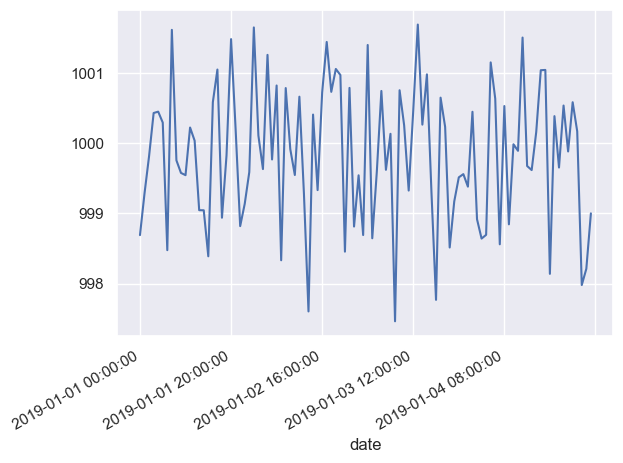

In [88]:
fig, ax = plt.subplots()
df['no1'][:100].plot()
fig.autofmt_xdate()
plt.savefig('LineChart.png')

### Generating a `pdf` plot

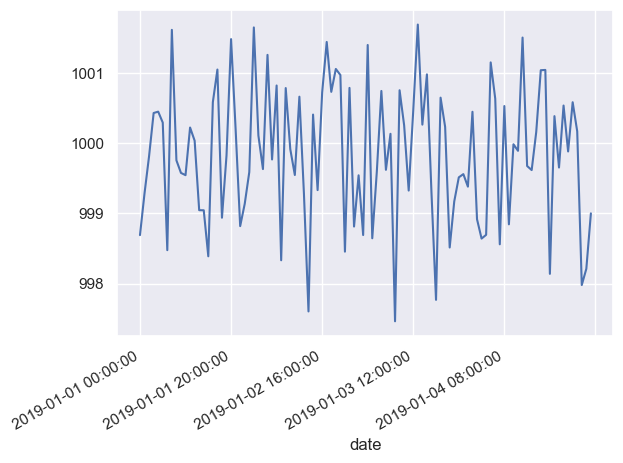

In [89]:
fig, ax = plt.subplots()
df['no1'][:100].plot()
fig.autofmt_xdate()
plt.savefig('LineChart.pdf')

### Generating plots

* There are various options for fine-tuning the appearance and quality of the plot. 
* Let's check that both plots have been written to the hard disk:

In [90]:
ls -l LineChart*

-rw-r--r--@ 1 nat  staff   9944 28 Apr 17:20 LineChart.pdf
-rw-r--r--@ 1 nat  staff  53783 28 Apr 17:20 LineChart.png


### Another pdf plot

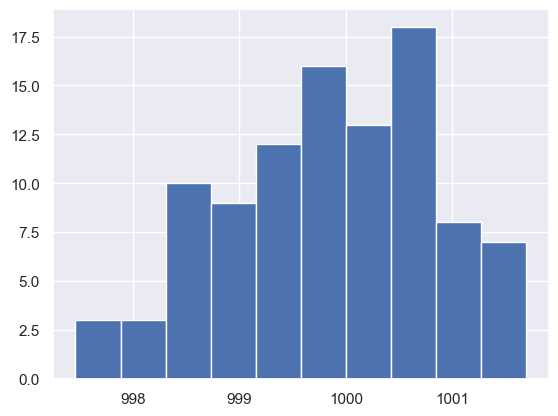

In [91]:
df['no1'][1:100].hist()
plt.savefig('Hist.pdf')

## Direct download from the internet: `pandas-datareader`

* Many data providers offer direct downloads through an API (application programming interface), an programming interface that controls data access and the data format.
* In other words, instead of manually downloading and subsequently importing a file, the data download can directly be incorporated into the program.
* The package `pandas-datareader` provides a convenient unified way of extracting data from various Internet sources into a pandas `DataFrame`.

### Installing `pandas-datareader`

* Installation via anaconda: go to environments in the left menubar, enter `datareader` in `search packages` and install. 
* Alternatively, use a terminal programme (command line) and type:  
    * `pip install pandas-datareader`  
* This is a frequently changing package... I had to use:
    * `pip install git+https://github.com/pydata/pandas-datareader.git`
* For more information, see [here](https://pandas-datareader.readthedocs.io/en/stable/index.html) and [here](https://anaconda.org/anaconda/pandas-datareader).

### Using `pandas-datareader`

Using TIINGO requires that you create a free account and obtain an API key.

In [92]:
import os
import pandas_datareader as pdr

In [93]:
df = pdr.get_data_tiingo('AAPL', api_key=os.getenv('TIINGO_API_KEY'))
df.head()

/var/folders/46/b127yp714m71zfmt9j7_lhwh0000gq/T/ipykernel_19676/158876764.py:1: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  df = pdr.get_data_tiingo('AAPL', api_key=os.getenv('TIINGO_API_KEY'))


close    high     low    open    volume  \
symbol date                                                                  
AAPL   2020-04-29 00:00:00+00:00  287.73  289.67  283.89  284.73  34320204   
       2020-04-30 00:00:00+00:00  293.80  294.53  288.35  289.96  45765968   
       2020-05-01 00:00:00+00:00  289.07  299.00  285.85  286.25  60154175   
       2020-05-04 00:00:00+00:00  293.16  293.69  286.32  289.17  33391986   
       2020-05-05 00:00:00+00:00  297.56  301.00  294.46  295.06  36937795   

                                   adjClose    adjHigh     adjLow    adjOpen  \
symbol date                                                                    
AAPL   2020-04-29 00:00:00+00:00  69.829629  70.300451  68.897694  69.101555   
       2020-04-30 00:00:00+00:00  71.302767  71.479932  69.980098  70.370831   
       2020-05-01 00:00:00+00:00  70.154836  72.564763  69.373369  69.470446   
       2020-05-04 00:00:00+00:00  71.147444  71.276071  69.487434  70.179105   
       2020-05-05 00:00:00+00:00  72.215287  73.050146  71.462943  71.608558   

                                  adjVolume  divCash  splitFactor  
symbol date                                                        
AAPL   2020-04-29 00:00:00+00:00  137280816      0.0          1.0  
       2020-04-30 00:00:00+00:00  183063872      0.0          1.0  
       2020-05-01 00:00:00+00:00  240616700      0.0          1.0  
       2020-05-04 00:00:00+00:00  133567944      0.0          1.0  
       2020-05-05 00:00:00+00:00  147751180      0.0          1.0

In [94]:
df.tail()

close      high       low     open  \
symbol date                                                             
AAPL   2025-04-21 00:00:00+00:00  193.16  193.8000  189.8112  193.265   
       2025-04-22 00:00:00+00:00  199.74  201.5900  195.9700  196.120   
       2025-04-23 00:00:00+00:00  204.60  208.0000  202.7990  206.000   
       2025-04-24 00:00:00+00:00  208.37  208.8299  202.9400  204.890   
       2025-04-25 00:00:00+00:00  209.28  209.7500  206.2000  206.365   

                                    volume  adjClose   adjHigh    adjLow  \
symbol date                                                                
AAPL   2025-04-21 00:00:00+00:00  46742537    193.16  193.8000  189.8112   
       2025-04-22 00:00:00+00:00  52976371    199.74  201.5900  195.9700   
       2025-04-23 00:00:00+00:00  52929165    204.60  208.0000  202.7990   
       2025-04-24 00:00:00+00:00  47310989    208.37  208.8299  202.9400   
       2025-04-25 00:00:00+00:00  38222258    209.28  209.7500  206.2000   

                                  adjOpen  adjVolume  divCash  splitFactor  
symbol date                                                                 
AAPL   2025-04-21 00:00:00+00:00  193.265   46742537      0.0          1.0  
       2025-04-22 00:00:00+00:00  196.120   52976371      0.0          1.0  
       2025-04-23 00:00:00+00:00  206.000   52929165      0.0          1.0  
       2025-04-24 00:00:00+00:00  204.890   47310989      0.0          1.0  
       2025-04-25 00:00:00+00:00  206.365   38222258      0.0          1.0